# Result — iOCV  ·  FUDS  ·  Fielddata



## Imports

In [ ]:
import pydpeet as eet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydpeet.process.analyze.extract.haf_cell_fitting import (
    get_best_half_cell_fit,
    fit_half_cells,
    plot_half_cell_match,
    dir_anode,
    dir_cathode,
)

from pydpeet.process.analyze.extract.lithium_amount import calculate_electrode_quantities
from pydpeet.process.analyze.extract.lli_lam import calculate_lli_lam

# Anchor generation (pauses -> rest voltages)
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

# Capacity + LLI/LAM over the jointly covered SOC range
from pydpeet.process.analyze.extract.capa_covered import (
    lli_lam_covered,
    estimate_capacity_covered_mAh,
    covered_soc_range,
)
from pydpeet.process.analyze.extract.capa_curvefit import build_full_cell_ocv_curve

eet.set_logging_style("ERROR")


PATH_B1 = "../../..input_data/Input_files_checkup/20231129133302-CheckUp-3-7-AM23NMC00020.xlsx"
PATH_B2 = "../../..input_data/Input_files_checkup/20240216101054-CheckUp-3-8-AM23NMC00020.xlsx"


CSV_PATH = "../../..input_data/Felddaten/vin38.csv"

---
# Section A — iOCV


### A.1) Load and Prepare

In [ ]:
df_raw_1_iocv = eet.read(config="neware_8_0_0_516", input_path=PATH_B1)
df_raw_2_iocv = eet.read(config="neware_8_0_0_516", input_path=PATH_B2)

df_seq_1_iocv = eet.add_primitive_segments(df_raw_1_iocv)
df_seq_2_iocv = eet.add_primitive_segments(df_raw_2_iocv)

df_cap_1_iocv = eet.add_capacity(df_raw_1_iocv, df_seq_1_iocv, neware_bool=True, config=eet.lgm50lt_nmc_4800)
df_cap_2_iocv = eet.add_capacity(df_raw_2_iocv, df_seq_2_iocv, neware_bool=True, config=eet.lgm50lt_nmc_4800)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_raw_1_iocv["Test_Time[s]"] / 3600, df_raw_1_iocv["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Time in [h]")
ax.set_ylabel("Voltage in [V]")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_raw_2_iocv["Test_Time[s]"] / 3600, df_raw_2_iocv["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Time in [h]")
ax.set_ylabel("Voltage in [V]")
plt.show()


### A.2) Extract iOCV Phases and Filter to Charge

In [41]:
df_ocv_1 = eet.extract_ocv_iocv(df=df_cap_1_iocv, config=eet.lgm50lt_nmc_4800, visualize=False)
df_ocv_2 = eet.extract_ocv_iocv(df=df_cap_2_iocv, config=eet.lgm50lt_nmc_4800, visualize=False)

dpf_1 = pd.concat(df_ocv_1, ignore_index=True)
dpf_1 = dpf_1.loc[:, ~dpf_1.columns.duplicated()]
df_charge_1 = dpf_1[dpf_1["iOCV_type"] == "Charge"]

dpf_2 = pd.concat(df_ocv_2, ignore_index=True)
dpf_2 = dpf_2.loc[:, ~dpf_2.columns.duplicated()]
df_charge_2 = dpf_2[dpf_2["iOCV_type"] == "Charge"]

print(f"B1 Charge-iOCV: {len(df_charge_1)} Samples, SOC {df_charge_1['SOC'].min():.2f}–{df_charge_1['SOC'].max():.2f}")
print(f"B2 Charge-iOCV: {len(df_charge_2)} Samples, SOC {df_charge_2['SOC'].min():.2f}–{df_charge_2['SOC'].max():.2f}")


B1 Charge-iOCV: 121 Samples, SOC 0.00–1.00
B2 Charge-iOCV: 119 Samples, SOC 0.00–0.97


### A.3) Half-Cell Fit on B1 and B2

In [ ]:
best_fit_iocv_1 = get_best_half_cell_fit(df_charge_1, full_cell_name="iOCV_B1")
best_fit_iocv_2 = get_best_half_cell_fit(df_charge_2, full_cell_name="iOCV_B2")

print("B1 (reference, fresh):")
print(best_fit_iocv_1[["RMSE[mV]", "Anode", "Cathode",
                       "Sol_Anode_Min", "Sol_Anode_Max",
                       "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)
print("\nB2 (aged):")
print(best_fit_iocv_2[["RMSE[mV]", "Anode", "Cathode",
                       "Sol_Anode_Min", "Sol_Anode_Max",
                       "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)


### A.4) Half-Cell Plots of the iOCV Fits

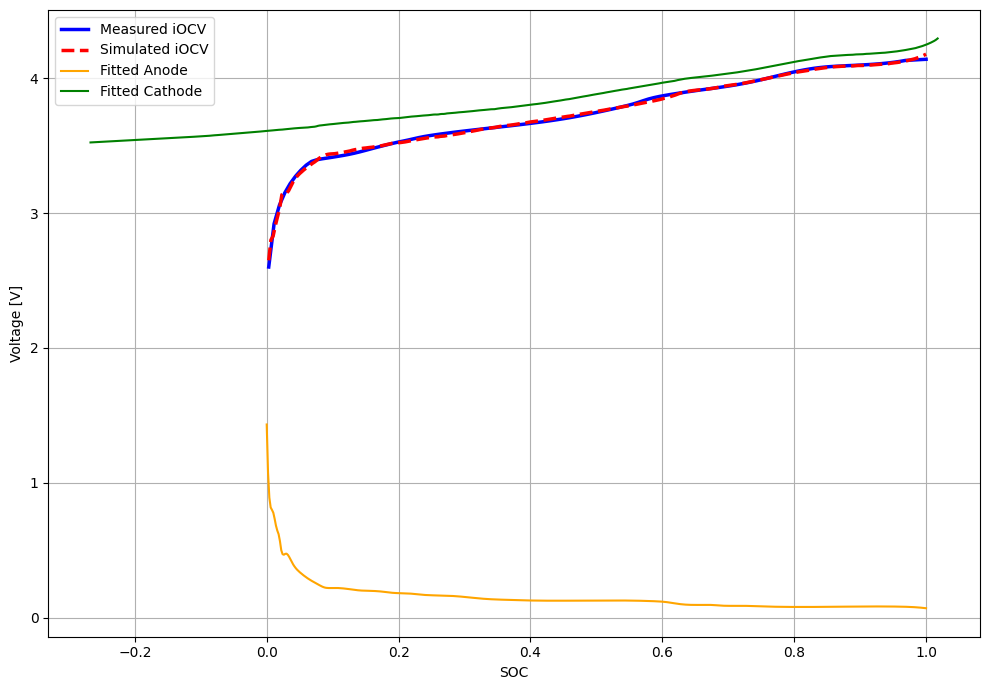

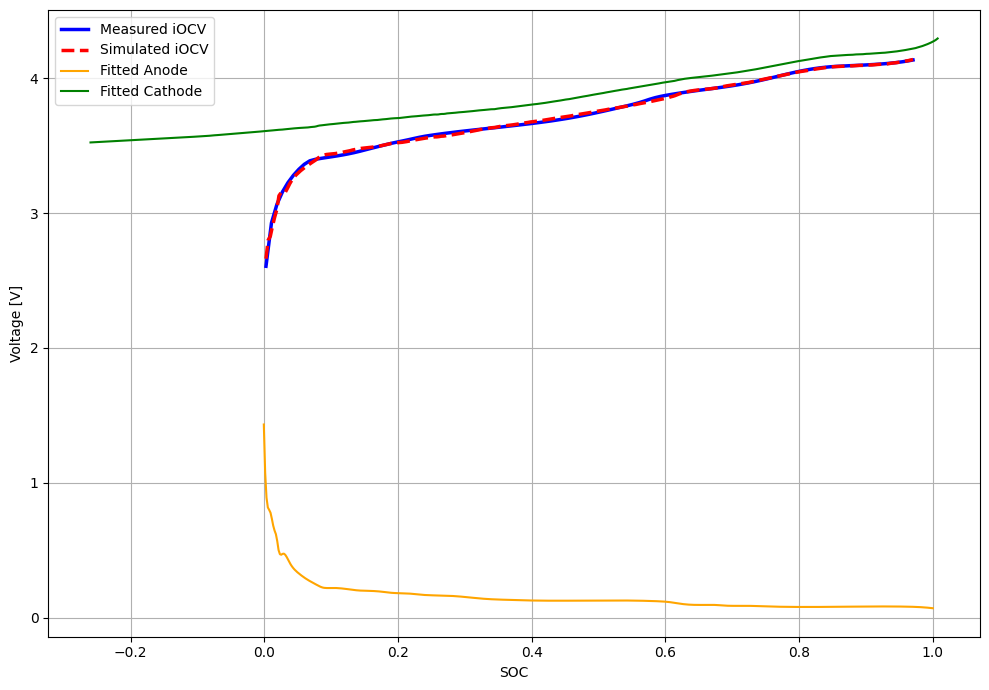

In [43]:
for label, best_fit, df_charge in [("B1", best_fit_iocv_1, df_charge_1),
                                    ("B2", best_fit_iocv_2, df_charge_2)]:
    anode_raw   = pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}")
    plot_half_cell_match(
        full_df       = df_charge,
        anode_df      = anode_raw,
        cathode_df    = cathode_raw,
        solution_array= best_fit["Solution_Array"].iloc[0],
        filename      = f"BestMatch_iOCV_{label}.png",
    )


### A.5) Capacity, Electrode Quantities and LLI / LAM

In [ ]:
# Capacity + LLI/LAM over the jointly covered SOC range (capa_covered)
def iocv_state(df_cap, df_charge, best_fit):
    t0, t1 = df_charge["Test_Time[s]"].min(), df_charge["Test_Time[s]"].max()
    seg = df_cap[(df_cap["Test_Time[s]"] >= t0) & (df_cap["Test_Time[s]"] <= t1)]
    anchors = pauses_to_ocv_simple(extract_pauses(seg, min_pause_duration_s=60))
    return {
        "df":         seg,
        "anchors":    anchors,
        "fit_result": best_fit,
        "anode_df":   pd.read_csv(f"{dir_anode}/{best_fit['Anode'].iloc[0]}"),
        "cathode_df": pd.read_csv(f"{dir_cathode}/{best_fit['Cathode'].iloc[0]}"),
    }

ref_state_iocv  = iocv_state(df_cap_1_iocv, df_charge_1, best_fit_iocv_1)
aged_state_iocv = iocv_state(df_cap_2_iocv, df_charge_2, best_fit_iocv_2)
lli_lam_iocv = lli_lam_covered(ref_state_iocv, aged_state_iocv)

cap_iocv_1 = lli_lam_iocv["Full_Cell_Cap_ref_mAh"].iloc[0]
cap_iocv_2 = lli_lam_iocv["Full_Cell_Cap_mAh"].iloc[0]
print(f"B1: {cap_iocv_1:8.1f} mAh   B2: {cap_iocv_2:8.1f} mAh")
print(f"joint SOC window: {lli_lam_iocv['SOC_window_lo'].iloc[0]:.3f} .. {lli_lam_iocv['SOC_window_hi'].iloc[0]:.3f}")

print("\nLLI / LAM (iOCV, B1 -> B2), measured within the joint SOC window:")
print(lli_lam_iocv[[
    "Full_Cell_Cap_ref_mAh", "Full_Cell_Cap_mAh", "SOH_pct",
    "LLI_mAh", "LLI_pct",
    "LAM_Anode_mAh", "LAM_Anode_pct",
    "LAM_Cathode_mAh", "LAM_Cathode_pct",
]].round(2).T)


---
# Section B — FUDS


### B.1) Add SOC and Extract FUDS Phase

In [ ]:
from pydpeet.process.analyze.extract.fuds import extract_fuds
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

# SOC is a prerequisite for extract_fuds and for anchor creation
df_soc_1_fuds = eet.add_soc(df_raw_1_iocv, df_seq_1_iocv,
                            standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY,
                            config=eet.lgm50lt_nmc_4800)
df_soc_2_fuds = eet.add_soc(df_raw_2_iocv, df_seq_2_iocv,
                            standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL_AND_EMPTY,
                            config=eet.lgm50lt_nmc_4800)

df_fuds_1 = extract_fuds(df_soc_1_fuds)
df_fuds_2 = extract_fuds(df_soc_2_fuds)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_fuds_1["Test_Time[s]"], df_fuds_1["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Time in s")
ax.set_ylabel("Voltage in V")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_fuds_2["Test_Time[s]"], df_fuds_2["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Time in s")
ax.set_ylabel("Voltage in V")
plt.show()


### B.2) Pauses → OCV Anchors → Half-Cell Fit

In [ ]:
results_fuds = {}

for label, df_fuds in [("B1", df_fuds_1), ("B2", df_fuds_2)]:
    df_pause = extract_pauses(df_fuds, min_pause_duration_s=10)
    anchors  = pauses_to_ocv_simple(df_pause)

    df_for_fit = (
        anchors[["SOC", "U"]].rename(columns={"U": "Voltage[V]"})
               .dropna().sort_values("SOC").drop_duplicates(subset="SOC").reset_index(drop=True)
    )

    best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"FUDS_{label}")
    results_fuds[label] = {"df_for_fit": df_for_fit, "best": best, "n_pauses": len(df_pause), "n_anchors": len(anchors)}

    print(f"FUDS {label}: {len(df_pause)} pauses → {len(anchors)} anchors → RMSE {best['RMSE[mV]'].iloc[0]:.2f} mV")
    print(best[["Anode", "Cathode",
                "Sol_Anode_Min", "Sol_Anode_Max",
                "Sol_Cathode_Min", "Sol_Cathode_Max"]].T)
    print()


### B.3) Half-Cell Plots of the FUDS Fits

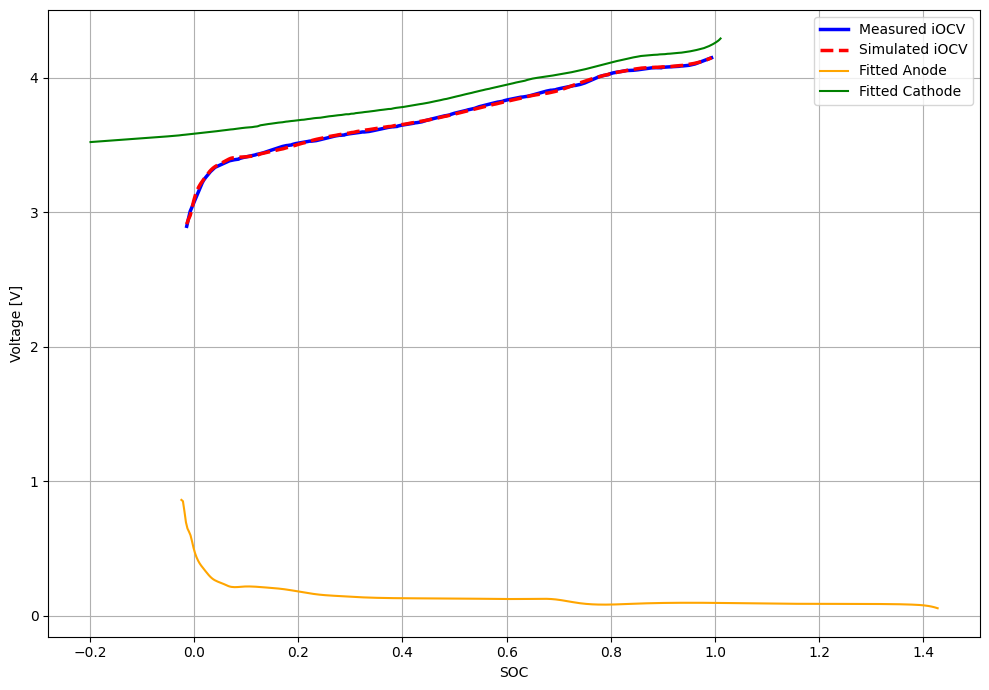

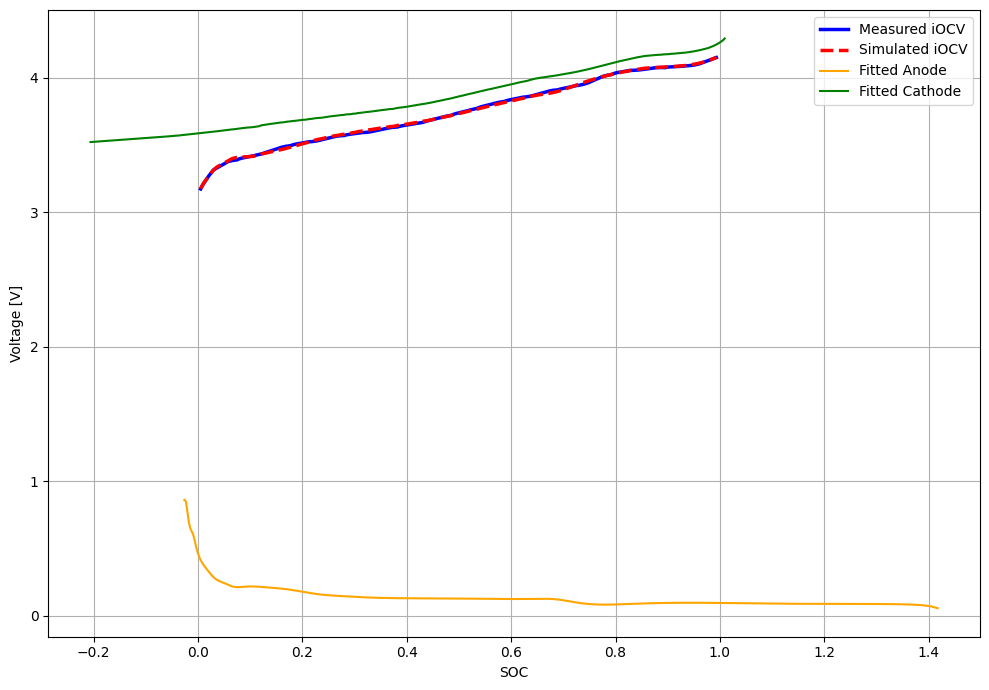

In [47]:
for label, r in results_fuds.items():
    anode_raw   = pd.read_csv(f"{dir_anode}/{r['best']['Anode'].iloc[0]}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{r['best']['Cathode'].iloc[0]}")
    plot_half_cell_match(
        full_df       = r["df_for_fit"],
        anode_df      = anode_raw,
        cathode_df    = cathode_raw,
        solution_array= r["best"]["Solution_Array"].iloc[0],
        filename      = f"BestMatch_FUDS_{label}.png",
    )


### B.4) Capacity, Electrode Quantities and LLI / LAM

In [ ]:
# Capacity + LLI/LAM (FUDS) over the jointly covered SOC window
def fuds_state(df_fuds, best):
    anchors = pauses_to_ocv_simple(extract_pauses(df_fuds, min_pause_duration_s=10))
    return {
        "df":         df_fuds,
        "anchors":    anchors,
        "fit_result": best,
        "anode_df":   pd.read_csv(f"{dir_anode}/{best['Anode'].iloc[0]}"),
        "cathode_df": pd.read_csv(f"{dir_cathode}/{best['Cathode'].iloc[0]}"),
    }

ref_state_fuds  = fuds_state(df_fuds_1, results_fuds["B1"]["best"])
aged_state_fuds = fuds_state(df_fuds_2, results_fuds["B2"]["best"])
lli_lam_fuds = lli_lam_covered(ref_state_fuds, aged_state_fuds)

cap_fuds_1 = lli_lam_fuds["Full_Cell_Cap_ref_mAh"].iloc[0]
cap_fuds_2 = lli_lam_fuds["Full_Cell_Cap_mAh"].iloc[0]
print(f"B1: {cap_fuds_1:8.1f} mAh   B2: {cap_fuds_2:8.1f} mAh")
print(f"joint SOC window: {lli_lam_fuds['SOC_window_lo'].iloc[0]:.3f} .. {lli_lam_fuds['SOC_window_hi'].iloc[0]:.3f}")

print("\nLLI / LAM (FUDS, B1 -> B2), measured within the joint SOC window:")
print(lli_lam_fuds[[
    "Full_Cell_Cap_ref_mAh", "Full_Cell_Cap_mAh", "SOH_pct",
    "LLI_mAh", "LLI_pct",
    "LAM_Anode_mAh", "LAM_Anode_pct",
    "LAM_Cathode_mAh", "LAM_Cathode_pct",
]].round(2).T)


### B.5) Comparison iOCV vs FUDS


In [ ]:
vergleich = pd.DataFrame({
    "iOCV":  lli_lam_iocv[["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].iloc[0],
    "FUDS":  lli_lam_fuds[["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].iloc[0],
})
vergleich["Δ (FUDS − iOCV) [pp]"] = vergleich["FUDS"] - vergleich["iOCV"]
print("Method comparison B1 → B2:")
print(vergleich.round(2))


### B.6) Comparison Using Fixed Electrode Pairs (Consistent Chemistry)



In [ ]:
# Cross-fits: each stage with the winning pair of the respective other stage
anode_iocv_name = best_fit_iocv_1['Anode'].iloc[0]              # iOCV winner (Ecker2015)
anode_fuds_name = results_fuds['B1']['best']['Anode'].iloc[0]   # FUDS winner (Chaouachi2021)
cathode_name    = best_fit_iocv_1['Cathode'].iloc[0]            # NMC811, Chen2020 (both stages)

anode_iocv_df = pd.read_csv(f'{dir_anode}/{anode_iocv_name}')
anode_fuds_df = pd.read_csv(f'{dir_anode}/{anode_fuds_name}')
cathode_df_x  = pd.read_csv(f'{dir_cathode}/{cathode_name}')

# iOCV fixed with the FUDS anode (Chaouachi)
fit_iocv_fix_1 = fit_half_cells(df_charge_1, anode_fuds_df, cathode_df_x,
                                anode_name=anode_fuds_name, cathode_name=cathode_name,
                                full_cell_name='iOCV_B1_fix')
fit_iocv_fix_2 = fit_half_cells(df_charge_2, anode_fuds_df, cathode_df_x,
                                anode_name=anode_fuds_name, cathode_name=cathode_name,
                                full_cell_name='iOCV_B2_fix')

# FUDS fixed with the iOCV anode (Ecker)
fit_fuds_fix_1 = fit_half_cells(results_fuds['B1']['df_for_fit'], anode_iocv_df, cathode_df_x,
                                anode_name=anode_iocv_name, cathode_name=cathode_name,
                                full_cell_name='FUDS_B1_fix')
fit_fuds_fix_2 = fit_half_cells(results_fuds['B2']['df_for_fit'], anode_iocv_df, cathode_df_x,
                                anode_name=anode_iocv_name, cathode_name=cathode_name,
                                full_cell_name='FUDS_B2_fix')

for name, fit in [('iOCV B1 (Anode Chaouachi)', fit_iocv_fix_1),
                  ('iOCV B2 (Anode Chaouachi)', fit_iocv_fix_2),
                  ('FUDS B1 (Anode Ecker)',     fit_fuds_fix_1),
                  ('FUDS B2 (Anode Ecker)',     fit_fuds_fix_2)]:
    print(f"{name}: RMSE {fit['RMSE[mV]'].iloc[0]:6.2f} mV | "
          f"a_min {fit['Sol_Anode_Min'].iloc[0]:.4f}  a_max {fit['Sol_Anode_Max'].iloc[0]:.4f}  "
          f"c_min {fit['Sol_Cathode_Min'].iloc[0]:.4f}  c_max {fit['Sol_Cathode_Max'].iloc[0]:.4f}")


In [ ]:
# Capacity + LLI/LAM for the fixed variants (same covered method as A.5/B.4)
ref_iocv_fix  = iocv_state(df_cap_1_iocv, df_charge_1, fit_iocv_fix_1)
aged_iocv_fix = iocv_state(df_cap_2_iocv, df_charge_2, fit_iocv_fix_2)
lli_lam_iocv_fix = lli_lam_covered(ref_iocv_fix, aged_iocv_fix)

ref_fuds_fix  = fuds_state(df_fuds_1, fit_fuds_fix_1)
aged_fuds_fix = fuds_state(df_fuds_2, fit_fuds_fix_2)
lli_lam_fuds_fix = lli_lam_covered(ref_fuds_fix, aged_fuds_fix)

print('iOCV fixed (Chaouachi):    '
      f"B1 {lli_lam_iocv_fix['Full_Cell_Cap_ref_mAh'].iloc[0]:7.1f} mAh   "
      f"B2 {lli_lam_iocv_fix['Full_Cell_Cap_mAh'].iloc[0]:7.1f} mAh   "
      f"SOH {lli_lam_iocv_fix['SOH_pct'].iloc[0]:6.2f} %")
print('FUDS fixed (Ecker):        '
      f"B1 {lli_lam_fuds_fix['Full_Cell_Cap_ref_mAh'].iloc[0]:7.1f} mAh   "
      f"B2 {lli_lam_fuds_fix['Full_Cell_Cap_mAh'].iloc[0]:7.1f} mAh   "
      f"SOH {lli_lam_fuds_fix['SOH_pct'].iloc[0]:6.2f} %")


In [ ]:

_idx = ['SOH_pct', 'LLI_pct', 'LAM_Anode_pct', 'LAM_Cathode_pct']
def _col(res):
    return [res[k].iloc[0] for k in _idx]

vergleich_rahmen = pd.DataFrame({
    'iOCV free (Ecker)':        _col(lli_lam_iocv),
    'FUDS fixed (Ecker)':       _col(lli_lam_fuds_fix),
    'iOCV fixed (Chaouachi)':   _col(lli_lam_iocv_fix),
    'FUDS free (Chaouachi)':    _col(lli_lam_fuds),
}, index=_idx).round(2)
vergleich_rahmen


---
# Section C — Fielddata

### C.1) Imports and Configuration

In [53]:
from pydpeet.process.analyze.extract.field_data_loader import (
    load_field_data_csv,
    split_by_time_window,
)
from pydpeet.process.analyze.extract.fit_real_data import fit_real_data

NROWS                  = None
WINDOW_DAYS            = 30
MIN_PAUSE_S            = 600
MIN_POINTS_PER_CHUNK   = 20
MAX_RMSE_MV            = 50.0


MIN_DSOC_PAIR          = 0.02        
MAX_CYCLING_RATIO      = 2.0         


SOC_COVERAGE_MIN       = 0.60        
CAP_MAD_K              = 3.0         

### C.2) Load Raw CSV and Split into 30-Day Chunks

In [ ]:
df_field = load_field_data_csv(CSV_PATH, nrows=NROWS)
print(f"Loaded: {len(df_field):,} samples, {df_field['Test_Time[s]'].iloc[-1]/86400:.1f} days")

chunks = split_by_time_window(df_field, window_days=WINDOW_DAYS)
print(f"{len(chunks)} chunks ({WINDOW_DAYS} days per window)")


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_field["Test_Time[s]"] / 86400, df_field["Voltage[V]"])
ax.grid(True)
ax.set_xlabel("Time in days")
ax.set_ylabel("Voltage in V")
plt.show()

### C.3) Find Consensus Half-Cell Pair Across All Chunks

In [ ]:
consensus = fit_real_data(
    df_field,
    window_days=WINDOW_DAYS,
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
)
print(consensus.head())

top = consensus.iloc[0]
anode_df   = pd.read_csv(f"{dir_anode}/{top['Anode']}")
cathode_df = pd.read_csv(f"{dir_cathode}/{top['Cathode']}")
print(f"\nFitting pair:  {top['Anode']}   +   {top['Cathode']}")
print(f"  median RMSE = {top['median_rmse']:.1f} mV  over {top['n_chunks']} chunks  ({top['wins']} wins)")


### C.4) Per-Chunk Pipeline (Covered, Global SOC Window, Plausibility Filter)


In [57]:
from pydpeet.process.analyze.extract.fit_real_data import evaluate_chunks


res = evaluate_chunks(
    chunks, top["Anode"], top["Cathode"],
    min_pause_duration_s=MIN_PAUSE_S,
    min_points=MIN_POINTS_PER_CHUNK,
    max_rmse_mv=MAX_RMSE_MV,
    min_dsoc_pair=MIN_DSOC_PAIR,
    max_cycling_ratio=MAX_CYCLING_RATIO,
    soc_coverage_min=SOC_COVERAGE_MIN,
    cap_mad_k=CAP_MAD_K,
)

chunk_data           = res["chunk_data"]
GLOBAL_WINDOW        = res["global_window"]
cap_per_chunk_mAh    = res["cap_per_chunk_mAh"]
fits_per_chunk       = res["fits_per_chunk"]
quantities_per_chunk = res["quantities_per_chunk"]
valid_ids            = res["valid_ids"]
soh_ids              = res["soh_ids"]
lli_ids              = list(soh_ids)
CAP_REF_mAh          = res["cap_ref_mAh"]


Gemeinsames SOC-Fenster über 16 Chunks: 0.367 .. 0.932  (Breite 0.565)
11 Chunks mit gültiger Kapazität: [0, 5, 6, 8, 11, 12, 15, 16, 23, 24, 28]
Cap-Ausreißer (> 3*MAD um Median 115.7 Ah): [23]
-> plausible Chunks: 10 [0, 5, 6, 8, 11, 12, 15, 16, 24, 28]
SOH-Referenzkapazität (Median der ersten 3 plausiblen Chunks): 128.3 Ah


### C.5) Overview Table of Chunk Results

In [ ]:
overview = pd.DataFrame({
    "chunk":         valid_ids,
    "RMSE_mV":       [float(fits_per_chunk[i]["RMSE[mV]"].iloc[0]) for i in valid_ids],
    "Cap_Ah":        [cap_per_chunk_mAh[i] / 1000 for i in valid_ids],
    "SOH_pct":       [cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in valid_ids],
    "C_Anode_Ah":    [quantities_per_chunk[i]["C_Anode_mAh"].iloc[0] / 1000 for i in valid_ids],
    "C_Cathode_Ah":  [quantities_per_chunk[i]["C_Cathode_mAh"].iloc[0] / 1000 for i in valid_ids],
    "Cap_plausible": [i in set(soh_ids) for i in valid_ids],
}).round(2)
overview

### C.6) LLI / LAM — Rolling and Cumulative (Plausible Chunks Only)



In [ ]:
# LLI/LAM only on the plausible chunks (pass-3 filter from C.4)
_cols = ["ref_chunk", "chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]

if len(lli_ids) < 2:
    print(f"Only {len(lli_ids)} chunk(s) with a plausible N/P ratio ({lli_ids}) — "
          f"LLI/LAM time series cannot be determined. (See C.7 for the SOH trend.)")
    rolling_df = pd.DataFrame(columns=_cols)
    cum_df     = pd.DataFrame(columns=_cols)
else:
    rolling_rows = []
    for ref_id, cur_id in zip(lli_ids[:-1], lli_ids[1:]):
        res = calculate_lli_lam(
            ref_quantities  = quantities_per_chunk[ref_id],
            aged_quantities = quantities_per_chunk[cur_id],
        )
        rolling_rows.append(res.assign(ref_chunk=ref_id, chunk=cur_id))
    rolling_df = pd.concat(rolling_rows, ignore_index=True)

    ref0 = lli_ids[0]
    cum_rows = []
    for cur_id in lli_ids[1:]:
        res = calculate_lli_lam(
            ref_quantities  = quantities_per_chunk[ref0],
            aged_quantities = quantities_per_chunk[cur_id],
        )
        cum_rows.append(res.assign(ref_chunk=ref0, chunk=cur_id))
    cum_df = pd.concat(cum_rows, ignore_index=True)

    print("Rolling LLI/LAM (vs. previous plausible chunk), joint SOC window:")
    print(rolling_df[_cols].round(2))
    print(f"\nCumulative (vs. chunk {ref0}):")
    print(cum_df[["chunk", "SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]].round(2))

### C.7) Plot — Incremental Δ, Cumulative, and SOH Trend

In [ ]:
if cum_df.empty:
    print("No LLI/LAM time series (too few plausible chunks) — only the SOH trend will be plotted.")
    fig, ax_soh = plt.subplots(figsize=(11, 4))
else:
    fig, (ax_roll, ax_cum, ax_soh) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    x_roll = rolling_df["chunk"].to_numpy()
    ax_roll.plot(x_roll, rolling_df["LLI_pct"],         "o-", label="ΔLLI",          color="tab:blue")
    ax_roll.plot(x_roll, rolling_df["LAM_Anode_pct"],   "s-", label="ΔLAM Anode",    color="tab:orange")
    ax_roll.plot(x_roll, rolling_df["LAM_Cathode_pct"], "^-", label="ΔLAM Cathode",  color="tab:green")
    ax_roll.axhline(0, color="0.5", lw=0.6)
    ax_roll.set_ylabel("Δ per 30-day step (%)")
    ax_roll.grid(True); ax_roll.legend()

    x_cum = cum_df["chunk"].to_numpy()
    ax_cum.plot(x_cum, cum_df["LLI_pct"],         "o-", label="LLI",         color="tab:blue")
    ax_cum.plot(x_cum, cum_df["LAM_Anode_pct"],   "s-", label="LAM Anode",   color="tab:orange")
    ax_cum.plot(x_cum, cum_df["LAM_Cathode_pct"], "^-", label="LAM Cathode", color="tab:green")
    ax_cum.axhline(0, color="0.5", lw=0.6)
    ax_cum.set_ylabel("cumulative (%)")
    ax_cum.grid(True); ax_cum.legend()

x_all   = np.array(soh_ids)
soh_all = np.array([cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in soh_ids])
ax_soh.plot(x_all, soh_all, "o-", color="tab:red", label="SOH = Cap_i / Cap_ref (median of first 3)")
ax_soh.axhline(100, color="0.6", lw=0.7, ls="--")
ax_soh.set_xlabel("Chunk index (30-day window)")
ax_soh.set_ylabel("SOH (%)")
ax_soh.grid(True); ax_soh.legend()

plt.tight_layout()
plt.show()

### C.7b) SOH Trend with Square-Root Fit



In [ ]:
from scipy.optimize import curve_fit

x = np.array(soh_ids, dtype=float)
y = np.array([cap_per_chunk_mAh[i] / CAP_REF_mAh * 100 for i in soh_ids])

if len(x) < 4:
    print(f"Only {len(x)} plausible chunks — too few for a reliable trend fit.")
else:
    # Square-root aging model, anchored at 100 %: SOH(x) = 100 - b * sqrt(x - x0)
    x0 = x.min()
    def sqrt_model(xx, b):
        return 100.0 - b * np.sqrt(xx - x0)

    (b,), _ = curve_fit(sqrt_model, x, y, p0=[1.0])
    x_fine = np.linspace(x.min(), x.max(), 400)
    y_fit  = sqrt_model(x_fine, b)

    trend_span = abs(sqrt_model(x.max(), b) - 100.0)          # trend swing over the time span
    noise      = float(np.std(y - sqrt_model(x, b)))          # chunk scatter around the fit

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.scatter(x, y, color="tab:red", alpha=0.35, s=40, zorder=2,
               label="Chunk values (plausible)")
    ax.plot(x_fine, y_fit, "--", color="tab:purple", lw=2.5, zorder=3,
            label=f"Square-root fit: SOH = 100 − {b:.2f}·√(x−{x0:.0f})")
    ax.axhline(100, color="0.6", lw=0.7, ls="--", zorder=1,
               label="100 % (median reference)")
    ax.axhline(80, color="0.7", lw=0.7, ls=":", zorder=1,
               label="80 % (end-of-life)")
    ax.set_xlabel("Chunk index (30-day window)")
    ax.set_ylabel("SOH (%)")
    ax.grid(True, alpha=0.4)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    print(f"Trend swing: {trend_span:.1f} pp | chunk scatter around the fit: ±{noise:.1f} pp")
    if b <= 0:
        print("No degrading trend (b ≤ 0) — no EOL forecast possible.")
    elif noise >= trend_span:
        x_eol = x0 + (20.0 / b) ** 2
        print(f"EOL estimate (SOH 80 %): chunk {x_eol:.1f} (~{x_eol*30:.0f} days) — "
              f"NOT reliable: scatter (±{noise:.1f} pp) ≥ trend swing ({trend_span:.1f} pp).")
    else:
        x_eol = x0 + (20.0 / b) ** 2
        print(f"End-of-life forecast (SOH 80 %): chunk {x_eol:.1f}  (~{x_eol*30:.0f} days)")

---
# Synthesis — Three Pipelines at a Glance



In [ ]:
_real = cum_df.iloc[-1] if not cum_df.empty else None
synth = pd.DataFrame({
    "iOCV (B1→B2)":          [lli_lam_iocv["SOH_pct"].iloc[0],
                              lli_lam_iocv["LLI_pct"].iloc[0],
                              lli_lam_iocv["LAM_Anode_pct"].iloc[0],
                              lli_lam_iocv["LAM_Cathode_pct"].iloc[0]],
    "FUDS (B1→B2)":          [lli_lam_fuds["SOH_pct"].iloc[0],
                              lli_lam_fuds["LLI_pct"].iloc[0],
                              lli_lam_fuds["LAM_Anode_pct"].iloc[0],
                              lli_lam_fuds["LAM_Cathode_pct"].iloc[0]],
    "Fielddata (cumulative final value)": [
        float(_real["SOH_pct"])         if _real is not None else float("nan"),
        float(_real["LLI_pct"])         if _real is not None else float("nan"),
        float(_real["LAM_Anode_pct"])   if _real is not None else float("nan"),
        float(_real["LAM_Cathode_pct"]) if _real is not None else float("nan"),
    ],
}, index=["SOH_pct", "LLI_pct", "LAM_Anode_pct", "LAM_Cathode_pct"]).round(2)
synth